## Environment Setup

This notebook uses the `hackdays-2026` conda environment. To create it from the provided `environment.yml`:

```
mamba env create -f environment.yml
conda activate hackdays-2026
```

> **Note:** We recommend `mamba` over `conda` for faster dependency resolution and install.
> If you don't have `mamba` installed: `conda install -c conda-forge mamba`

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import earthaccess
import tempfile

## Column Definitions

The HiCARS ice thickness files have a fixed 12-column schema documented in each
file's comment header. We define the column names here so they can be passed to
`read_icethk` at parse time — this lets us standardize naming across both IR1HI2
and IR2HI2 files, which use the same schema but slightly different header lengths.

Two names differ from the raw files:
- `THK` → `ICE_THICK`
- `PARTIAL_BED_REFLECT` → `BED_REFLECT`

In [2]:
COLUMNS = [
    "YEAR", "DOY", "SOD",
    "LON", "LAT",
    "ICE_THICK", "SRF_RNG", "BED_ELEVATION", "SURFACE_ELEVATION",
    "BED_REFLECT", "SRF_REFLECT", "AIRCRAFT_ROLL"
]

## Authentication

You will need a free NASA Earthdata account to download data. If you don't have one,
register at [urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov).

`earthaccess.login()` will prompt for your credentials interactively. To avoid
entering them each time, you can persist them to a `.netrc` file:

```python
earthaccess.login(persist=True)  # only needs to be run once
```

In [4]:
earthaccess.login()

Enter your Earthdata Login username:  roma8902
Enter your Earthdata password:  ········


## Reprojection and Projected Coordinates

The raw files store positions as longitude/latitude in **WGS-84 (EPSG:4326)**, but
geostatistical methods like kriging require a **projected coordinate system** where
distances are in meters rather than degrees.

We reproject to **Antarctic Polar Stereographic (EPSG:3031)**, which is the standard
projection for Antarctic data and minimizes distortion at high southern latitudes.

We also write the projected coordinates as explicit `X` and `Y` columns alongside
the geometry. This is because `gstatsim` expects a plain DataFrame with numeric
`X` and `Y` columns in meters — it doesn't know how to read from a geometry column
directly.

In [5]:
def build_geoparquet(input_dir: str | Path, out_path: str | Path):
    """
    Batch-convert a directory of IceBridge HiCARS ice thickness text files
    to a single GeoParquet file.

    Reads all ``*.txt`` files in ``input_dir``, concatenates them, drops
    rows with missing coordinates, and constructs point geometries from
    LON/LAT (EPSG:4326). The data is reprojected to Antarctic polar
    stereographic (EPSG:3031) and projected ``X``/``Y`` coordinates are
    written as explicit columns alongside the geometry for direct use
    with gstatsim.

    Parameters
    ----------
    input_dir : str or Path
        Directory containing ``*_icethk.txt`` files (IR1HI2 and/or IR2HI2).
    out_path : str or Path
        Destination path for the output GeoParquet file.

    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame in EPSG:3031 with all input columns plus ``X``, ``Y``,
        ``source_file``, and ``instrument``.
    """
    input_dir = Path(input_dir)
    files = sorted(input_dir.glob("*.txt"))
    print(f"Found {len(files)} files")

    chunks = [read_icethk(f) for f in files]
    df = pd.concat(chunks, ignore_index=True)
    print(f"Total rows (including NaN positions): {len(df):,}")

    df = df.dropna(subset=["LON", "LAT"])
    print(f"Rows with valid positions: {len(df):,}")

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["LON"], df["LAT"]),
        crs="EPSG:4326",
    )

    gdf = gdf.to_crs("EPSG:3031")
    gdf["X"] = gdf.geometry.x
    gdf["Y"] = gdf.geometry.y

    gdf.to_parquet(out_path, compression="snappy")
    print(f"Written → {out_path}")
    return gdf

## Reading Individual Flight Line Files

Each granule downloaded from NSIDC is a single flight line — one `.txt` file per
aircraft transit. The files have a variable-length comment header (65 lines for
IR2HI2, 72 lines for IR1HI2) followed by space-delimited data.

`read_icethk` handles a single file: it detects the header length automatically
by scanning for the `Length_of_header` metadata field, parses the data block, and
tags each row with the source filename and instrument version (`HiCARS1` or `HiCARS2`)
for provenance tracking.

> **Note:** Rows with missing `LON`/`LAT` are retained at this stage — these occur
> at the start and end of flight lines where GPS lock was lost. They are dropped
> in `build_geoparquet` when we construct the point geometries.

In [6]:
def read_icethk(path: Path) -> pd.DataFrame:
    """
    Read a single IceBridge HiCARS ice thickness text file into a DataFrame.

    Parses the variable-length comment header by scanning for the
    ``Length_of_header`` metadata field, then reads the space-delimited
    data block. Missing values (``nan`` in the raw files) are preserved
    as ``NaN``. A ``source_file`` column and an ``instrument`` column
    (``HiCARS1`` or ``HiCARS2``, inferred from the filename prefix) are
    appended for provenance tracking.

    Parameters
    ----------
    path : Path
        Path to a ``*_icethk.txt`` file (IR1HI2 or IR2HI2 format).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: YEAR, DOY, SOD, LON, LAT, ICE_THICK,
        SRF_RNG, BED_ELEVATION, SURFACE_ELEVATION, BED_REFLECT,
        SRF_REFLECT, AIRCRAFT_ROLL, source_file, instrument.
        Rows with missing LON/LAT are retained at this stage.
    """
    with open(path) as f:
        for i, line in enumerate(f):
            if "Length_of_header:" in line:
                header_lines = int(line.split(":")[-1].strip().split()[0])
                break

    df = pd.read_csv(
        path,
        skiprows=header_lines,
        sep=r"\s+",
        names=COLUMNS,
        na_values="nan",
    )
    df["source_file"] = path.name
    df["instrument"] = "HiCARS1" if "IR1HI2" in path.name else "HiCARS2"
    return df

In [7]:
out_path = Path("data/icethk_all.parquet").expanduser()
out_path.parent.mkdir(parents=True, exist_ok=True)

## Downloading IceBridge HiCARS Ice Thickness Data

We use [`earthaccess`](https://earthaccess.readthedocs.io/en/stable/) to search for and download 
granules from NASA Earthdata. `earthaccess` handles authentication and download in just a few lines 
of code — no manual file browsing required.

> **Finding a concept ID**  
> Each NASA Earthdata collection has a unique `concept_id` used to filter search results.  
> To find it, go to the dataset landing page (links below), click **"View data in Earthdata Search"**, 
> and copy the ID from the URL (e.g. `...?p=C3204979277-NSIDC_CPRD...`).  
> 
> Dataset landing pages:
> - [IR1HI2 — IceBridge HiCARS 1 L2 Ice Thickness](https://nsidc.org/data/ir1hi2/versions/1)
> - [IR2HI2 — IceBridge HiCARS 2 L2 Ice Thickness](https://nsidc.org/data/ir2hi2/versions/1)

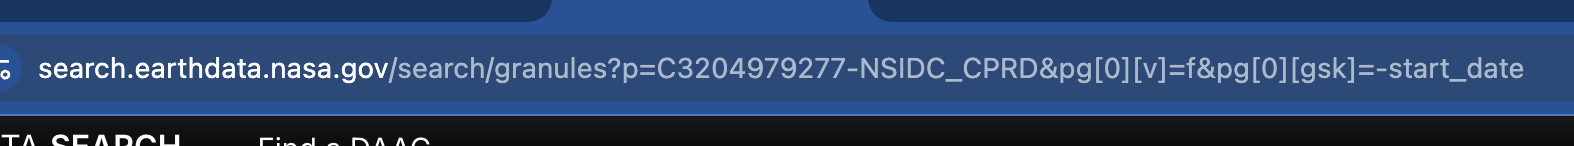

Full `search_data` parameter reference: [earthaccess docs](https://earthaccess.readthedocs.io/en/stable/api/#earthaccess.api.search_data)

## Download and Convert

This cell downloads 860 granules (~several GB) to a temporary directory and converts
them to a single GeoParquet. **This will take a while** depending
on your connection. The temp directory is cleaned up automatically after the parquet is written.

In [8]:
with tempfile.TemporaryDirectory() as tmpdir:
    for concept_id in ["C3204979277-NSIDC_CPRD", "C3204982997-NSIDC_CPRD"]:
        results = earthaccess.search_data(concept_id=concept_id)
        print(f"{concept_id}: {len(results)} granules")
        earthaccess.download(results, local_path=tmpdir)
        
    gdf = build_geoparquet(tmpdir, out_path)

C3204979277-NSIDC_CPRD: 243 granules


QUEUEING TASKS | :   0%|          | 0/243 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/243 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/243 [00:00<?, ?it/s]

C3204982997-NSIDC_CPRD: 617 granules


QUEUEING TASKS | :   0%|          | 0/617 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/617 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/617 [00:00<?, ?it/s]

Found 860 files
Total rows (including NaN positions): 9,700,516
Rows with valid positions: 9,372,683
Written → data/icethk_all.parquet


In [9]:
gdf = gpd.read_parquet(out_path)
print(gdf.shape)
print(gdf.dtypes)
gdf.head()

(9372683, 17)
YEAR                    int64
DOY                     int64
SOD                   float64
LON                   float64
LAT                   float64
ICE_THICK             float64
SRF_RNG               float64
BED_ELEVATION         float64
SURFACE_ELEVATION     float64
BED_REFLECT           float64
SRF_REFLECT           float64
AIRCRAFT_ROLL         float64
source_file            object
instrument             object
geometry             geometry
X                     float64
Y                     float64
dtype: object


,YEAR,DOY,SOD,LON,LAT,ICE_THICK,SRF_RNG,BED_ELEVATION,SURFACE_ELEVATION,BED_REFLECT,SRF_REFLECT,AIRCRAFT_ROLL,source_file,instrument,geometry,X,Y
531,2009,2,33057.5535,161.096539,-80.058225,532.63,1458.61,-520.62,-1458.61,-50.00,-21.90,11.11,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350801.917 -1024406.626),350801.916733,-1.024407e+06
532,2009,2,33057.8034,161.097043,-80.058075,532.42,1458.25,-520.06,12.36,-48.79,-17.63,11.09,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350798.224 -1024425.242),350798.223863,-1.024425e+06
533,2009,2,33058.0535,161.097547,-80.057925,NaN,1460.26,NaN,10.35,NaN,-16.40,11.08,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350794.531 -1024443.859),350794.530694,-1.024444e+06
534,2009,2,33058.3032,161.098051,-80.057774,NaN,1464.00,NaN,6.60,NaN,-19.77,10.98,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350790.873 -1024462.579),350790.872679,-1.024463e+06
535,2009,2,33058.5532,161.098556,-80.057624,NaN,1459.10,NaN,11.50,NaN,-14.17,10.64,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350787.161 -1024481.202),350787.161030,-1.024481e+06


## Next Steps

The GeoParquet is now ready for geostatistical analysis. See the variogram notebook
for how to load this file into `gstatsim` for kriging bed elevation.